In [3]:
# load in tools
import os, gzip, shutil, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import unary_union

warnings.filterwarnings("ignore")
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)
print("Ready")

Ready


In [4]:
# load in tools
import os, gzip, shutil, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import unary_union

warnings.filterwarnings("ignore")
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)
print("Ready")

Ready


In [5]:
def download(url, filename):
    path = os.path.join("data", filename)
    if not os.path.exists(path):
        print("Downloading", filename, "...")
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as response, open(path, "wb") as out:
            shutil.copyfileobj(response, out)
    return path

# noaa hurricane tracks
download("https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-"
"stewardship-ibtracs/v04r01/access/csv/ibtracs.NA.list.v04r01.csv", "ibtracs.csv")

# coastlines
download("https://naciscdn.org/naturalearth/50m/physical/ne_50m_land.zip", "land.zip")

# monthly gulf oil product from EIA
download("https://www.eia.gov/dnav/pet/hist_xls/MCRFP3FM2m.xls", "eia.xls")

# platforms and production per platform from BOEM
for name in ["Platform/Files/PlatStrucRawData.zip", "Production/Files/ProdByPlatformRawData.zip"]:
    z = download("https://www.data.boem.gov/" + name, name.split("/")[-1])
    zipfile.ZipFile(z).extractall("data")
print("Downloads complete")

Downloads complete


In [6]:
# picking 10 storms
STORMS = {2008: ["GUSTAV", "IKE"], 2012: ["ISAAC"], 2017: ["NATE"], 2019: ["BARRY"], 2020: ["LAURA", "DELTA", "ZETA"], 2021: ["IDA"], 2024: ["FRANCINE"]}
all_tracks = pd.read_csv("data/ibtracs.csv", skiprows=[1], low_memory=False)
keep = [s in STORMS and n in STORMS[s] for s, n in zip(all_tracks.SEASON, all_tracks.NAME)]
tracks = all_tracks[keep].copy()

tracks["storm"] = tracks.NAME.str.title() + " " + tracks.SEASON.astype(str)
tracks["time"] = pd.to_datetime(tracks.ISO_TIME, utc=True)
tracks["LAT"] = tracks.LAT.astype(float)
tracks["LON"] = tracks.LON.astype(float)

tracks = tracks.sort_values(["storm", "time"])

print(tracks.groupby("storm").size().to_string())


storm
Barry 2019        47
Delta 2020        59
Francine 2024     44
Gustav 2008       95
Ida 2021          77
Ike 2008         119
Isaac 2012        96
Laura 2020        79
Nate 2017         62
Zeta 2020         46


In [8]:
# draw gulf and find when storms enter
land = gpd.read_file("data/land.zip").to_crs(4326).union_all()

# eastern edge of the gulf will be defined yucatan channel to cuba then to florida straits
outline = Polygon([(-87.10, 21.60), (-84.95, 21.87), (-83.00, 22.97), (-83.00, 24.58), (-82.58, 24.58), (-81.10, 25.10), (-81.10, 31.5), (-98.5, 31.5), (-98.5, 17.5), (-87.10, 17.5)])

# water
GULF = outline.difference(land)

rows = []
for storm, t in tracks.groupby("storm"):
    inside = [GULF.contains(Point(x,y)) for x, y in zip(t.LON, t.LAT)]
    i = int(np.argmax(inside))
    if i > 0:
        a, b = t.iloc[i - 1], t.iloc[i]
        seg = LineString([(a.LON, a.LAT), (b.LON, b.LAT)])
        hit = seg.intersection(GULF.boundary)
        hit = hit if hit.geom_type == "Point" else list(hit.geoms)[0]
        entry = a.time + (b.time - a.time) * (seg.project(hit) / seg.length)
    else:
        entry = t.iloc[0].time
    rows.append({"storm": storm, "entry_utc": entry.floor("min")})
events = pd.DataFrame(rows)
print(events.to_string(index=False))

        storm                 entry_utc
   Barry 2019 2019-07-10 12:00:00+00:00
   Delta 2020 2020-10-07 16:01:00+00:00
Francine 2024 2024-09-08 18:00:00+00:00
  Gustav 2008 2008-08-31 00:53:00+00:00
     Ida 2021 2021-08-28 00:52:00+00:00
     Ike 2008 2008-09-09 20:23:00+00:00
   Isaac 2012 2012-08-27 02:24:00+00:00
   Laura 2020 2020-08-25 03:08:00+00:00
    Nate 2017 2017-10-07 01:12:00+00:00
    Zeta 2020 2020-10-27 02:29:00+00:00


In [10]:
# what happend, peak % of gulf oil shut in BSEE daily reports
actual = pd.Series({"Gustav 2008": 100.0, "Ike 2008": 99.9, "Isaac 2012": 94.99, "Nate 2017": 92.61, "Barry 2019": 72.82, "Laura 2020": 84.3, "Delta 2020": 91.72, "Zeta 2020": 84.8, "Ida 2021": 95.65, "Francine 2024": 41.74})

# IKE and LAURA hut while oil was already shut from previous storm gustav, marco
# going to count only the new shut-ins as a share of oil thats still running

actual["Ike 2008"] = 100 * (99.9 - 77.5) / (100 - 77.5)
acutal["Laura 2020"] = 100 * (84.3 - 13.0) / (100 - 13.0)
print(actual.round(1).to_string())


Gustav 2008      100.0
Ike 2008          99.6
Isaac 2012        95.0
Nate 2017         92.6
Barry 2019        72.8
Laura 2020        84.3
Delta 2020        91.7
Zeta 2020         84.8
Ida 2021          95.6
Francine 2024     41.7


In [11]:
#where oil is - barrels per day at every producing platform
b = all_tracks[(all_tracks.SEASON.astype(int) >= 2007) & (all_tracks.NAME != "NOT_NAMED")].copy()
b = b[b.LAT.astype(float).between(17, 31.5) & b.LON.astype(float).between(-98.5, -80.9)]
b = gpd.GeoDataFrame(b, geometry=gpd.points_from_xy(b.LON.astype(float), b.LAT.astype(float)), crs=4326)
stormy_months = set(pd.to_datetime(b[b.within(GULF)].ISO_TIME).dt.to_period("M"))

prod = pd.read_csv("data/ProdByPlatformRawData/mv_prod_by_platform_all.txt", low_memory=False)
prod["month"] = pd.to_datetime(prod.PRODUCTION_DATE, format="%m/%d/%Y").dt.to_period("M")
structures = pd.read_csv("data/PlatStrucRawData/mv_platstruc_structures.txt", low_memory=False)
where = structures.groupby(["COMPLEX_ID_NUM", "STRUCTURE_NUMBER"])[["LATITUDE", "LONGITUDE"]].first()
eia = pd.read_excel("data/eia.xls", sheet_name="Data 1", skiprows=2)
eia.columns = ["date", "thousand_bpd"]
eia["month"] = pd.to_datetime(eia.date).dt.to_period("M")

platforms, check = [], []
for _, e in events.iterrows():
    m = e.entry_utc.tz_convert(None).to_period("M") - 1
    while m in stormy_months:
        m -= 1
    p = prod[(prod.month == m) & (prod.BOPD > 0)]
    p = p.merge(where, left_on=["COMPLEX_ID_NUM", "STRUCTURE_NUMBER"], right_index=True)
    p = p.dropna(subset=["LATITUDE"]).assign(storm=e.storm)
    platforms.append(p)
    eia_bpd = eia.loc[eia.month == m, "thousand_bpd"].iloc[0] * 1000
    check.append({"storm": e.storm, "month": str(m), "platforms": len(p), "our_total_bpd": int(p.BOPD.sum()), "EIA_bpd": int(eia_bpd), "difference_%": round(100 * (p.BOPD.sum() / eia_bpd - 1), 2)})
platforms = pd.concat(platforms)
print(pd.DataFrame(check).to_string(index=False))

        storm   month  platforms  our_total_bpd  EIA_bpd  difference_%
   Barry 2019 2019-06        696        1928598  1928000          0.03
   Delta 2020 2020-05        268        1604491  1604000          0.03
Francine 2024 2024-05        333        1803297  1803000          0.02
  Gustav 2008 2008-06       1453        1329287  1326000          0.25
     Ida 2021 2021-05        471        1816357  1816000          0.02
     Ike 2008 2008-06       1453        1329287  1326000          0.25
   Isaac 2012 2012-07       1124        1256199  1252000          0.34
   Laura 2020 2020-05        268        1604491  1604000          0.03
    Nate 2017 2017-05        786        1686786  1686000          0.05
    Zeta 2020 2020-05        268        1604491  1604000          0.03


In [12]:
# turn a storm track into the area including its winds
MAP = "+proj=aeqd +lat_0=26 +lon_0=-90 +units=m" # map projection measured in meters
NM = 1852 

def wind_area(track, radius_columns):
    t = track.copy()
    radius = t[radius_columns].apply(pd.to_numeric, errors="coerce").max(axis=1).fillna(0) * NM
    pts = gpd.GeoSeries(gpd.points_from_xy(t.LON, t.LAT), crs=4326).to_crs(MAP)
    circles = [p.buffer(r) if r > 0 else None for p, r in zip(pts, radius)]
    pieces = []
    for c1, c2 in zip(circles[:-1], circles[1:]): # connect each circle to the next one
        if c1 is not None and c2 is not None:
            pieces.append(unary_union([c1, c2]).convex_hull)
        elif c1 is not None:
            pieces.append(c1)
    if circles[-1] is not None:
        pieces.append(circles[-1])
    return unary_union(pieces)
def share_inside(area, storm):
    p = platforms[platforms.storm == storm]
    pts = gpd.GeoSeries(gpd.points_from_xy(p.LONGITUDE, p.LATITUDE), crs=4326).to_crs(MAP)
    inside = pts.within(area).values
    return 100 * p.BOPD[inside].sum() / p.BOPD.sum()
print("ready")

ready


In [13]:
# predicted % of gulf oil at risk based off of where storm actually went
Q = ["NE", "SE", "SW", "NW"]
areas, results = {}, []
for storm, t in tracks.groupby("storm"):
    a34 = wind_area(t, ["USA_R34_" + q for q in Q]) # tropical storm force
    a64 = wind_area(t, ["USA_R64_" + q for q in Q]) # hurricane force
    areas[storm] = (a34, a64)
    results.append({"storm": storm, "pred_34kt": round(share_inside(a34, storm), 1), "pred_64kt": round(share_inside(a64, storm), 1), "actual": round(actual[storm], 1)})
results = pd.DataFrame(results).set_index("storm")
print(results.to_string())

               pred_34kt  pred_64kt  actual
storm                                      
Barry 2019          96.0        0.5    72.8
Delta 2020          20.8        0.1    91.7
Francine 2024       27.6        5.5    41.7
Gustav 2008         94.9       61.7   100.0
Ida 2021            77.9       28.0    95.6
Ike 2008           100.0       44.2    99.6
Isaac 2012          92.9       47.7    95.0
Laura 2020          67.1       25.7    84.3
Nate 2017           75.7       31.6    92.6
Zeta 2020           92.1       20.1    84.8


In [14]:
# same test using NHC forecast from ~3 days before entry
def read_forecasts(path):
    rows = []
    for line in gzip.open(path, "rt", encoding="utf-8", errors="ignore"):
        f = [x.strip() for x in line.split(",")]
        if len(f) < 11 or f[4] != "OFCL": # OFCL = official NHC forecast
            continue
        wind = f[11] if len(f) > 11 else "0"
        r = max(int(x) if x.isdigit() else 0 for x in f[13:17]) if len(f) > 16 else 0
        rows.append({"issued": pd.Timestamp(f[2][:8] + " " + f[2][8:] + ":00", tz="UTC"), "hour": int(f[5]), "LAT": float(f[6][:-1]) / 10, "LON": -float(f[7][:-1]) / 10, "r34": r if wind == "34" else 0})
    d = pd.DataFrame(rows)
    return d.groupby(["issued", "hour", "LAT", "LON"]).r34.max().reset_index()
ids = tracks.groupby("storm").USA_ATCF_ID.first()
fc = []
for _, e in events.iterrows():
    code, year = ids[e.storm][2:4], e.storm[-4:]
    f = read_forecasts(download(f"https://ftp.nhc.noaa.gov/atcf/archive/{year}/aal{code}{year}.dat.gz", f"forecast_{e.storm.replace(' ', '_')}.dat.gz"))
    target = e.entry_utc - pd.Timedelta(hours=72)
    issued = sorted(f.issued.unique())
    pick = max([i for i in issued if i <= target], default=issued[0]) # else first advisory
    one = f[(f.issued == pick) & (f.hour <= 120)].sort_values("hour").copy()
    last = one.loc[one.r34 > 0, "hour"].max() # radii stop at hour 72
    one.loc[one.hour > last, "r34"] = one.loc[one.hour <= last, "r34"].max()
    area = wind_area(one, ["r34"])
    areas[e.storm] = areas[e.storm] + (area,)
    p = platforms[platforms.storm == e.storm]
    fc.append({"storm": e.storm, "issued": pick.strftime("%b %d %HZ"), "pred_forecast": round(share_inside(area, e.storm), 1), "forecast_bpd": share_inside(area, e.storm) / 100 * p.BOPD.sum()})
results = results.join(pd.DataFrame(fc).set_index("storm"))
print(results[["pred_34kt", "pred_64kt", "pred_forecast", "actual", "issued"]].to_string())

               pred_34kt  pred_64kt  pred_forecast  actual      issued
storm                                                                 
Barry 2019          96.0        0.5           56.5    72.8  Jul 10 12Z
Delta 2020          20.8        0.1           81.8    91.7  Oct 04 18Z
Francine 2024       27.6        5.5            3.7    41.7  Sep 08 18Z
Gustav 2008         94.9       61.7           80.2   100.0  Aug 28 00Z
Ida 2021            77.9       28.0           89.1    95.6  Aug 26 12Z
Ike 2008           100.0       44.2            1.5    99.6  Sep 06 18Z
Isaac 2012          92.9       47.7           47.9    95.0  Aug 24 00Z
Laura 2020          67.1       25.7           94.8    84.3  Aug 22 00Z
Nate 2017           75.7       31.6           26.8    92.6  Oct 04 12Z
Zeta 2020           92.1       20.1           97.4    84.8  Oct 24 18Z


               average_miss_pts  too_low_by_pts  rank_match
pred_34kt                  17.5            11.3        0.47
pred_64kt                  59.3            59.3        0.79
pred_forecast              32.5            27.8       -0.12


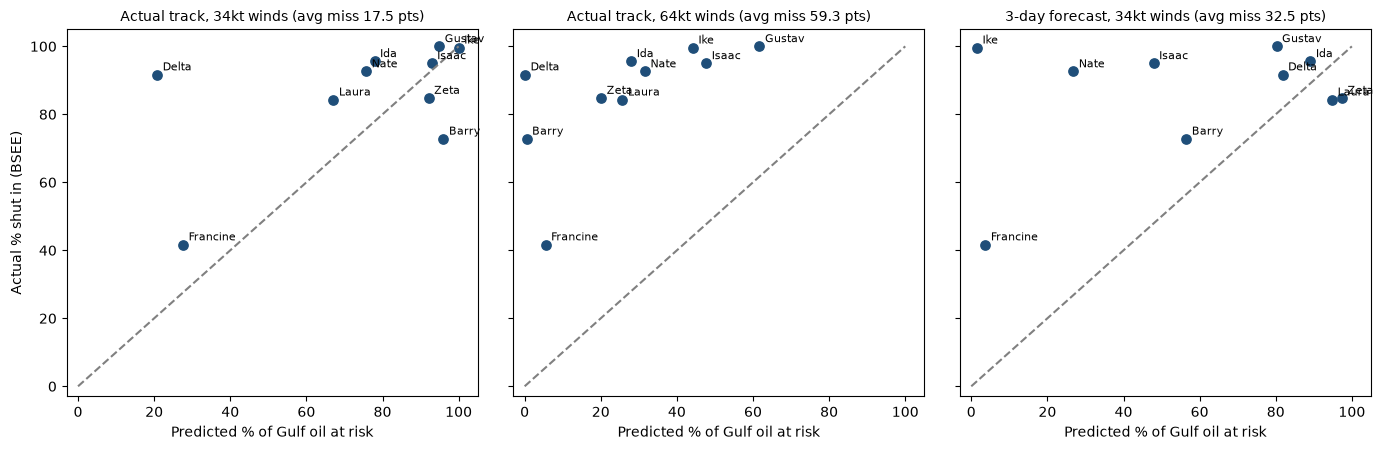

In [15]:
# score each method Average miss
score = {}
for col in ["pred_34kt", "pred_64kt", "pred_forecast"]:
    miss = results[col] - results.actual
    score[col] = {"average_miss_pts": round(miss.abs().mean(), 1), "too_low_by_pts": round(-miss.mean(), 1), "rank_match": round(results[[col, "actual"]].corr(method="spearman").iloc[0, 1], 2)}
print(pd.DataFrame(score).T.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
titles = {"pred_34kt": "Actual track, 34kt winds", "pred_64kt": "Actual track, 64kt winds", "pred_forecast": "3-day forecast, 34kt winds"}

for ax, col in zip(axes, titles):
    ax.scatter(results[col], results.actual, s=45, color="#1f4e79")
    ax.plot([0, 100], [0, 100], ls="--", color="grey") # perfect-prediction line
    for storm, r in results.iterrows():
        ax.annotate(storm.split()[0], (r[col], r.actual), xytext=(4, 3), textcoords="offset points", fontsize=8)
    ax.set_title(f"{titles[col]} (avg miss {score[col]['average_miss_pts']} pts)", fontsize=10)
    ax.set_xlabel("Predicted % of Gulf oil at risk")
    ax.set_xlim(-3, 105); ax.set_ylim(-3, 105)
axes[0].set_ylabel("Actual % shut in (BSEE)")
plt.tight_layout(); plt.savefig("figures/predicted_vs_actual.png", dpi=150); plt.show()

In [16]:
# daily prices oil, 3 energy stocks, SP500 as market
import yfinance as yf
prices = yf.download(["CL=F", "MUR", "CVX", "XLE", "^GSPC"], start="2007-06-01", end="2024-12-31", progress=False, auto_adjust=True)["Close"]
prices = prices.rename(columns={"CL=F": "WTI"})
returns = np.log(prices.where(prices > 0)).diff() # daily % moves
returns.loc["2020-04-20":"2020-04-22", "WTI"] = np.nan # the day oil went negative
print(prices.tail(3).round(2).to_string())

Ticker        WTI     CVX    MUR    XLE    ^GSPC
Date                                            
2024-12-26  69.62  133.86  26.46  40.12  6037.59
2024-12-27  70.60  133.88  26.45  40.12  5970.84
2024-12-30  70.99  133.02  27.31  40.11  5906.94


In [17]:
# event study, did prices move more than normal around each storm?
ASSETS = ["WTI", "MUR", "CVX", "XLE"]
days = returns.index

def abnormal(asset, day):
    i = days.get_loc(day)
    normal = returns.iloc[i - 120:i - 9][[asset, "^GSPC"]].dropna() # 120 to 10 days before
    model = sm.OLS(normal[asset], sm.add_constant(normal["^GSPC"])).fit()
    window = returns.iloc[i - 1:i + 4] # day -1 to day +3
    expected = model.params["const"] + model.params["^GSPC"] * window["^GSPC"]
    return (window[asset] - expected)

rows, paths = [], {}
for _, e in events.iterrows():
    et = e.entry_utc.tz_convert("America/New_York")
    start = et.normalize().tz_localize(None) + pd.Timedelta(days=1 if et.hour >= 16 else 0)
    day = days[days >= start][0] # first trading day at or after entry
    for a in ASSETS:
        ar = abnormal(a, day)
        paths[(e.storm, a)] = ar
        rows.append({"storm": e.storm, "asset": a, "CAR_%": 100 * ar.sum()})
cars = pd.DataFrame(rows).pivot(index="storm", columns="asset", values="CAR_%")
print(cars.round(2).to_string())

asset           CVX    MUR    WTI   XLE
storm                                  
Barry 2019     0.53  -4.99   1.96  0.08
Delta 2020    -1.28 -11.53  -6.14 -2.62
Francine 2024 -1.60  -3.95  -0.12 -2.90
Gustav 2008   -5.90  -7.23 -10.45 -6.25
Ida 2021      -0.04   2.06   2.82  1.06
Ike 2008       1.12  -8.24 -15.14 -4.49
Isaac 2012    -0.15  -2.02  -0.66 -0.53
Laura 2020    -3.21  -2.66  -1.37 -2.25
Nate 2017      0.05  -3.33  -0.38 -0.54
Zeta 2020      4.98   6.03  -6.55  5.03


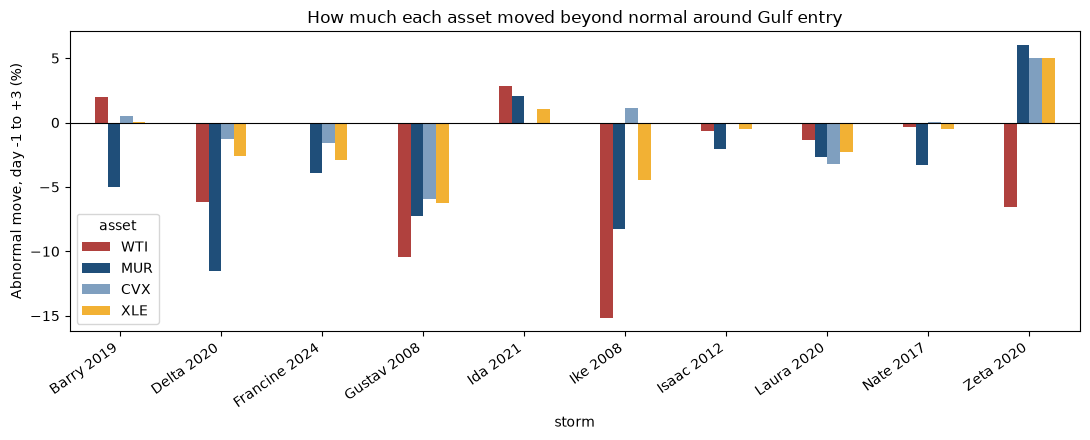

In [18]:
# charting abnormal moves per storm
cars[ASSETS].plot(kind="bar", figsize=(11, 4.5), color=["#b0413e", "#1f4e79", "#7f9fbf", "#f2b134"])
plt.axhline(0, color="black", lw=0.8)
plt.ylabel("Abnormal move, day -1 to +3 (%)")
plt.title("How much each asset moved beyond normal around Gulf entry")
plt.xticks(rotation=35, ha="right")
plt.tight_layout(); plt.savefig("figures/abnormal_moves.png", dpi=150); plt.show()

       sample asset  avg_move_%  slope_%_per_million_bpd  p_value
all 10 storms   WTI       -3.60                     2.36    0.529
all 10 storms   MUR       -3.59                     3.21    0.176
all 10 storms   CVX       -0.55                     0.12    0.932
all 10 storms   XLE       -1.34                     2.34    0.073
 without 2008   WTI       -1.31                    -1.47    0.449
 without 2008   MUR       -2.55                     2.55    0.316
 without 2008   CVX       -0.09                     0.96    0.525
 without 2008   XLE       -0.33                     2.00    0.161


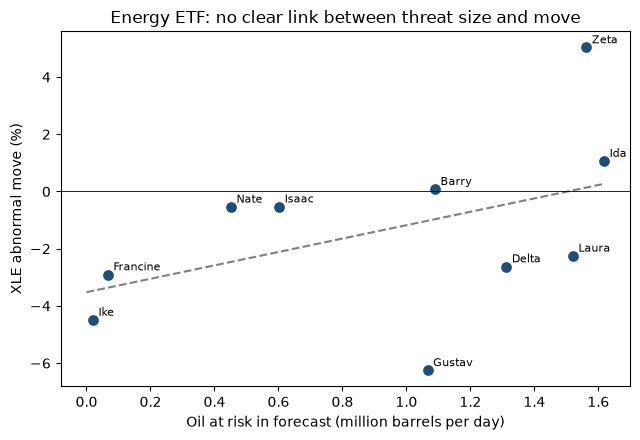

In [19]:
# test if bigger storm threat = bigger price move? regress the move on barrels at risk
data = cars.join(results.forecast_bpd / 1e6) # million barrels per day at risk
out = []

for sample, d in [("all 10 storms", data), ("without 2008", data.drop(["Gustav 2008", "Ike 2008"]))]:
    for a in ASSETS:
        m = sm.OLS(d[a], sm.add_constant(d.forecast_bpd)).fit(cov_type="HC1")
        out.append({"sample": sample, "asset": a, "avg_move_%": round(d[a].mean(), 2), "slope_%_per_million_bpd": round(m.params.iloc[1], 2), "p_value": round(m.pvalues.iloc[1], 3)})
print(pd.DataFrame(out).to_string(index=False))

plt.figure(figsize=(6.5, 4.5))
plt.scatter(data.forecast_bpd, data.XLE, s=45, color="#1f4e79")
for storm, r in data.iterrows():
    plt.annotate(storm.split()[0], (r.forecast_bpd, r.XLE), xytext=(4, 3), textcoords="offset points", fontsize=8)
fit = np.polyfit(data.forecast_bpd, data.XLE, 1)
xs = np.linspace(0, data.forecast_bpd.max(), 10)
plt.plot(xs, fit[0] * xs + fit[1], ls="--", color="grey")
plt.axhline(0, color="black", lw=0.6)
plt.xlabel("Oil at risk in forecast (million barrels per day)")
plt.ylabel("XLE abnormal move (%)")
plt.title("Energy ETF: no clear link between threat size and move")
plt.tight_layout(); plt.savefig("figures/xle_vs_barrels.png", dpi=150); plt.show()

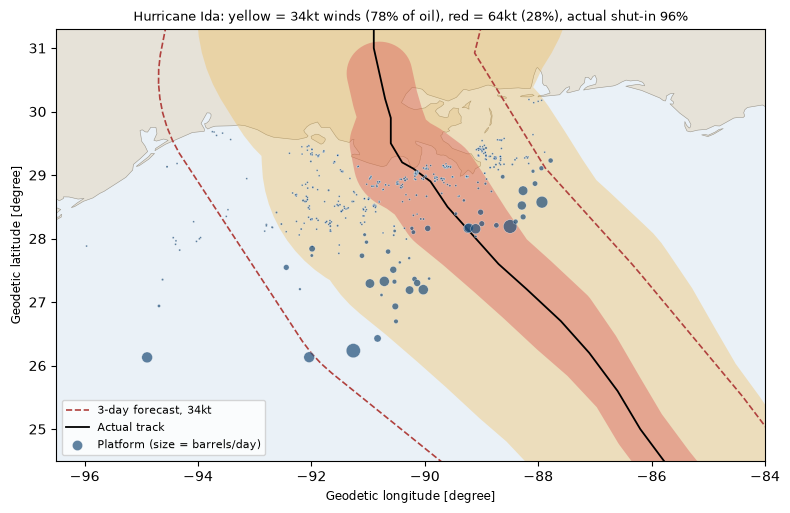

In [20]:
 # map ida as best example
a34, a64, afc = [gpd.GeoSeries([g], crs=MAP).to_crs(4326) for g in areas["Ida 2021"]]
ida = tracks[tracks.storm == "Ida 2021"]
p = platforms[platforms.storm == "Ida 2021"]
fig, ax = plt.subplots(figsize=(8, 6.2))
ax.set_facecolor("#eaf1f7")
gpd.read_file("data/land.zip").plot(ax=ax, color="#e6e2d8", edgecolor="#9a958a", lw=0.4)
afc.boundary.plot(ax=ax, color="#b0413e", lw=1.2, ls="--", label="3-day forecast, 34kt")
a34.plot(ax=ax, color="#f2b134", alpha=0.3)
a64.plot(ax=ax, color="#d9534f", alpha=0.4)
ax.plot(ida.LON, ida.LAT, color="black", lw=1.3, label="Actual track")
ax.scatter(p.LONGITUDE, p.LATITUDE, s=p.BOPD / 1500 + 2, color="#1f4e79", alpha=0.7, edgecolor="white", lw=0.3, zorder=5, label="Platform (size = barrels/day)")
ax.set_xlim(-96.5, -84); ax.set_ylim(24.5, 31.3); ax.set_aspect(1.12)
r = results.loc["Ida 2021"]
ax.set_title(f"Hurricane Ida: yellow = 34kt winds ({r.pred_34kt:.0f}% of oil), "f"red = 64kt ({r.pred_64kt:.0f}%), actual shut-in {r.actual:.0f}%", fontsize=9)
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.savefig("figures/ida_map.png", dpi=150); plt.show()